Scenario
A learning platform wants to understand course engagement and completion behavior.


In [9]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from faker import Faker
import random

Create a dataset of at least 300 course enrollments with:
student_id, course_name, progress_percent, completion_days, rating


In [10]:
data=[]
fake=Faker()
courses=["Btech","BCA","MBA","BSC","MSC"]
for i in range(300):
    data.append({
        "student_id":fake.uuid4(),
        "course_name":random.choice(courses),
        "progress_percent":fake.random_int(min=0,max=100),
        "completion_days":fake.random_int(min=1,max=120),
        "rating":fake.random_int(min=1,max=5)
    })
df=pd.DataFrame(data)
df.to_csv("Course_Analysis.csv",index=False)
df.head(10)

,student_id,course_name,progress_percent,completion_days,rating
0,c0001de3-dd8a-455b-9306-6dd63b1e29fe,MBA,21,118,3
1,8183b91f-c9e5-4391-b674-78835ac37dc1,MBA,32,8,2
2,7a00cb53-c0fe-4171-b74e-59212b2eb16b,BSC,13,28,3
3,d5ca6651-3fa2-4e7f-8fdd-02befeaa77fe,MBA,98,98,4
4,2465a119-a188-4744-b646-5f32c36fd62a,BCA,70,66,5
5,d7a62003-3db5-424b-94df-651dac81f830,Btech,18,69,2
6,e3406516-dbe0-4a00-9d36-36fdcbe5b382,Btech,23,27,1
7,71b5e725-2163-44ac-aac5-4312ad51d89a,BCA,54,2,4
8,16c97701-fc24-46b6-987c-f8542ffde5d1,MBA,2,69,2
9,e621cf2d-2bc2-49ef-9909-14a78384c437,MSC,60,111,3


Using Pandas:
Identify courses with poor completion performance.


In [11]:
# poor completion performance means low average student 
avg_progress=df.groupby("course_name")["progress_percent"].mean().reset_index()
poor_progress=avg_progress[avg_progress["progress_percent"]<50]
print("Courses with low average (poor performance) is:",poor_progress)

Courses with low average (poor performance) is:   course_name  progress_percent
2       Btech         46.637931
3         MBA         48.323077


Compute average completion time per course.

In [12]:
avg_completion=df.groupby(df["course_name"])["completion_days"].mean().reset_index()
avg_completion.rename(columns={"completion_days":"avg_completion_days"},inplace=True)
print(avg_completion)


  course_name  avg_completion_days
0         BCA            58.594203
1         BSC            59.851064
2       Btech            63.620690
3         MBA            53.000000
4         MSC            59.032787


Using NumPy:
Perform statistical analysis on completion duration.


In [13]:
arr=df["completion_days"].to_numpy()
stats={
    "Mean":np.mean(arr),
    "Median":np.median(arr),
    "Standard Deviation":np.std(arr),
    "Variance":np.var(arr),
    "Minimum":np.min(arr),
    "Max":np.max(arr)
    
}
print(stats)

{'Mean': np.float64(58.64), 'Median': np.float64(58.5), 'Standard Deviation': np.float64(36.24146428241184), 'Variance': np.float64(1313.4437333333333), 'Minimum': np.int64(1), 'Max': np.int64(120)}


Simulate improved progress scenarios.(progress percent improved by 15 for each student)

In [14]:
improvement=15
df["improved_progress_percent"]=df["progress_percent"]+improvement
df["improved_progress_percent"]=df["improved_progress_percent"].clip(upper=100)
print(df[["course_name","progress_percent","improved_progress_percent"]].head(10))

  course_name  progress_percent  improved_progress_percent
0         MBA                21                         36
1         MBA                32                         47
2         BSC                13                         28
3         MBA                98                        100
4         BCA                70                         85
5       Btech                18                         33
6       Btech                23                         38
7         BCA                54                         69
8         MBA                 2                         17
9         MSC                60                         75


Using a visualization library:
Visualize completion time distribution.

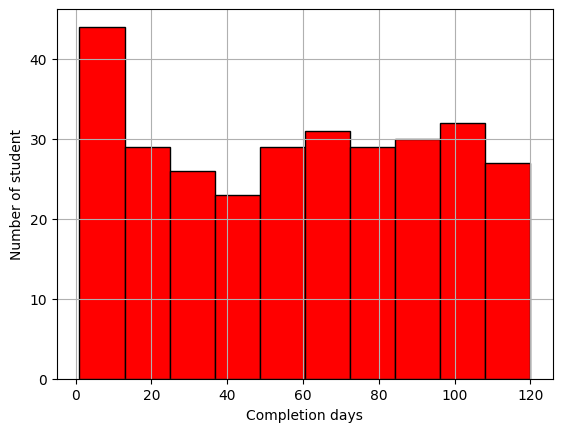

In [15]:
plt.hist(df["completion_days"],bins=10,color="red",edgecolor="black")
plt.grid()#bins divide data set in 20 part or what we give number
plt.xlabel("Completion days")
plt.ylabel("Number of student")

plt.show()

Compare average ratings across courses.

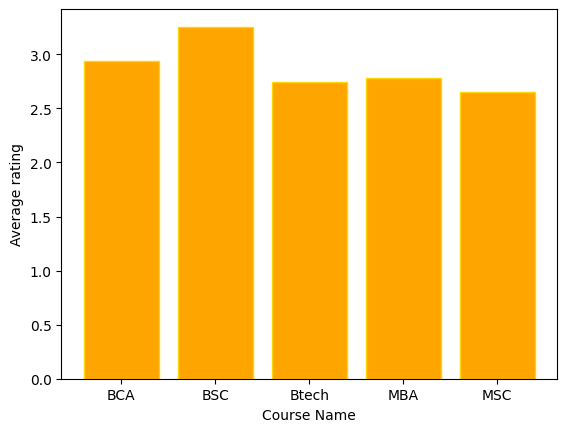

In [16]:
avg_ratings=df.groupby("course_name")["rating"].mean().reset_index()
avg_ratings.rename(columns={"rating":"avg_rating"},inplace=True)
plt.bar(avg_ratings["course_name"],avg_ratings["avg_rating"],color="orange",edgecolor="gold")
plt.xlabel("Course Name")
plt.ylabel("Average rating")
plt.show()